# Q4 — The Gender Gap and Deprivation

**Research Question:** How does the performance gap between boys and girls change across different levels of regional deprivation?

---

## Background

Girls consistently outperform boys at GCSE level in England. However, the size of this gap is not uniform: it may widen or narrow depending on the level of deprivation in a Local Authority. Understanding how deprivation interacts with gender is important for targeting educational interventions.

## Approach

We use the pre-cleaned `final_df_gender.csv` produced by `AL_school_performance_0906.ipynb`. This dataset contains:
- **Performance metrics** (Attainment 8 average and subject-level scores) broken down by `sex` (Boys / Girls) for each Local Authority and academic year.
- **Deprivation metrics** (IMD score and sub-domain scores) aggregated to Local Authority level from the 2019 Indices of Multiple Deprivation (IMD).

### Key analytical steps
1. Load and validate the dataset.
2. Compute the **gender gap** (Girls − Boys Attainment 8) per LA per year.
3. Categorise Local Authorities into **deprivation quintiles** based on their IMD score.
4. Explore how the gender gap varies across deprivation quintiles — overall and over time.
5. Examine subject-level gaps (English, Maths, EBacc, Humanities, Languages).
6. Correlation analysis between deprivation score and gender gap size.

### Note on COVID-19
The academic years 2019/20 and 2020/21 had **no formal GCSE examinations** — results were based on teacher-assessed grades. These years are flagged in all charts and treated with caution.

## 1. Imports and Setup

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plotting style for all plots
sns.set_theme(style="whitegrid", palette="muted", font_scale=1)
plt.rcParams.update({
    "figure.dpi": 120, # increases image resolution for sharper figures
    "axes.spines.top": False, # Removes the top border from plots
    "axes.spines.right": False, # Removes the right border from plots
    "font.family": "DejaVu Sans" # Uses a widely supported font
})

# Colour palette
GIRL_COL  = "#E05C5C"   # warm coral (girls)
BOY_COL   = "#4A7FBD"   # steel blue (boys)
GAP_COL   = "#7C5CBF"   # purple (gap between girls and boys)
COVID_COL = "#FFD700"   # yellow (COVID years)

# Quintile palette (low deprivation = green, high = red)
QUINT_PALETTE = ["#1a9850", "#91cf60", "#fee08b", "#fc8d59", "#d73027"]

## 2. Load and Validate the Data

In [17]:
# Load the gender dataset
df = pd.read_csv("data/final_df_gender.csv")

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSex categories: {df['sex'].unique()}")
print(f"Years covered:  {sorted(df['end_year'].unique())}")
print(f"Local Authorities: {df['new_la_code'].nunique()}")

Shape: (2084, 28)

Columns: ['time_period', 'new_la_code', 'la_name', 'pupil_count', 'sex', 'attainment8_average', 'ebacc_aps_average', 'attainment8eng_average', 'attainment8mat_average', 'attainment8ebacc_average', 'ebacceng_aps_average', 'ebaccmat_aps_average', 'ebaccsci_aps_average', 'ebacchum_aps_average', 'ebacclan_aps_average', 'end_year', 'merge_la_code', 'UTLA19CD', 'UTLA19NM', 'imd_score', 'income_score', 'employment_score', 'health_score', 'crime_score', 'barriers_score', 'living_env_score', 'idaci_score', 'children_subdomain']

Sex categories: <StringArray>
['Boys', 'Girls']
Length: 2, dtype: str
Years covered:  [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Local Authorities: 153


In [18]:
# Quick sanity check: every LA-year pair should have both Boys AND Girls
pair_counts = (
    df.groupby(["new_la_code", "end_year"])["sex"]
    .count()
    .reset_index(name="n_rows")
)

print("Rows per LA-year pair (should all be 2):")
print(pair_counts["n_rows"].value_counts())

# Preview the data
df.head(4)

Rows per LA-year pair (should all be 2):
n_rows
2    1042
Name: count, dtype: int64


,time_period,new_la_code,la_name,pupil_count,sex,attainment8_average,ebacc_aps_average,attainment8eng_average,attainment8mat_average,attainment8ebacc_average,...,UTLA19NM,imd_score,income_score,employment_score,health_score,crime_score,barriers_score,living_env_score,idaci_score,children_subdomain
0,202425,E06000001,Hartlepool,569,Boys,40.5,3.54,9.0,8.3,11.6,...,Hartlepool,34.853121,0.226241,0.182017,0.87419,0.582345,13.764345,7.298431,0.266483,0.109310
1,202425,E06000001,Hartlepool,554,Girls,44.5,3.79,10.1,8.2,12.2,...,Hartlepool,34.853121,0.226241,0.182017,0.87419,0.582345,13.764345,7.298431,0.266483,0.109310
2,202425,E06000002,Middlesbrough,794,Boys,39.5,3.45,8.6,8.2,11.3,...,Middlesbrough,40.443116,0.251326,0.190605,1.19207,0.680523,14.206791,12.533547,0.300384,0.417465
3,202425,E06000002,Middlesbrough,800,Girls,42.6,3.65,9.8,7.8,11.7,...,Middlesbrough,40.443116,0.251326,0.190605,1.19207,0.680523,14.206791,12.533547,0.300384,0.417465


## 3. Compute the Gender Gap

We pivot the data so that each row represents one Local Authority in one academic year, with separate columns for Girls and Boys performance. The **gender gap** is defined as:

> **Gender Gap = Girls' Attainment 8 − Boys' Attainment 8**

A positive value means girls outperform boys; a negative value means boys outperform girls.

In [19]:
# Performance metric columns
perf_cols = [
    "attainment8_average",
    "attainment8eng_average",
    "attainment8mat_average",
    "attainment8ebacc_average",
    "ebacc_aps_average",
    "ebacceng_aps_average",
    "ebaccmat_aps_average",
    "ebaccsci_aps_average",
    "ebacchum_aps_average",
    "ebacclan_aps_average",
]

# IMD / deprivation columns (same value for both sexes in a given LA-year)
imd_cols = [
    "imd_score", "income_score", "employment_score",
    "health_score", "crime_score", "barriers_score",
    "living_env_score", "idaci_score", "children_subdomain"
]

# Convert data from long format to wide format by separate the dataset into boys and girls. The Local Authority code, name, and academic year are used as the index to align records correctly.
boys  = df[df["sex"] == "Boys" ].set_index(["new_la_code", "la_name", "end_year"])
girls = df[df["sex"] == "Girls"].set_index(["new_la_code", "la_name", "end_year"])



# Create a new dataset for gender-gap analysis

# We start by copying the deprivation variables from the boys dataset. These values are identical for boys and girls, so either dataset could be used as the source.
gap = boys[imd_cols].copy()

# Add gender-specific attainment columns and calculation of gender gap
for col in perf_cols:
    gap[f"boys_{col}"]  = boys[col]
    gap[f"girls_{col}"] = girls[col]
    gap[f"gap_{col}"]   = girls[col] - boys[col]   # positive means that girls outperform boys

# Convert Local Authority identifiers and year back into regular columns for easier analysis.
gap = gap.reset_index()

# Inspect the resulting dataset
print(f"Gap dataset shape: {gap.shape}")
gap[["la_name", "end_year", "imd_score",
     "boys_attainment8_average", "girls_attainment8_average",
     "gap_attainment8_average"]].head(8)

Gap dataset shape: (1042, 42)


,la_name,end_year,imd_score,boys_attainment8_average,girls_attainment8_average,gap_attainment8_average
0,Hartlepool,2025,34.853121,40.5,44.5,4.0
1,Middlesbrough,2025,40.443116,39.5,42.6,3.1
2,Redcar and Cleveland,2025,29.841330,42.6,46.2,3.6
3,Stockton-on-Tees,2025,25.244108,42.9,47.2,4.3
4,Darlington,2025,26.787000,42.0,46.6,4.6
5,Halton,2025,32.875684,40.4,43.7,3.3
6,Warrington,2025,18.955480,46.8,50.3,3.5
7,Blackburn with Darwen,2025,35.813626,42.4,48.6,6.2


### 3.1 Choice of Mean vs. Median for Exploratory Data Analysis (EDA)

To determine whether the mean or median is the more appropriate measure of central tendency for our analysis, we compare the distributions of the raw attainment scores (for boys and girls separately) against the distributions of the gender gaps.

The code cell below generates box plots for all subject metrics showing:
* **Boys' attainment score distribution** (blue box)
* **Girls' attainment score distribution** (pink box)
* **Gender gap distribution** (purple box)

On each plot, the **mean** is indicated by a green dashed line and the **median** by an orange dotted line to visually check their proximity and symmetry.

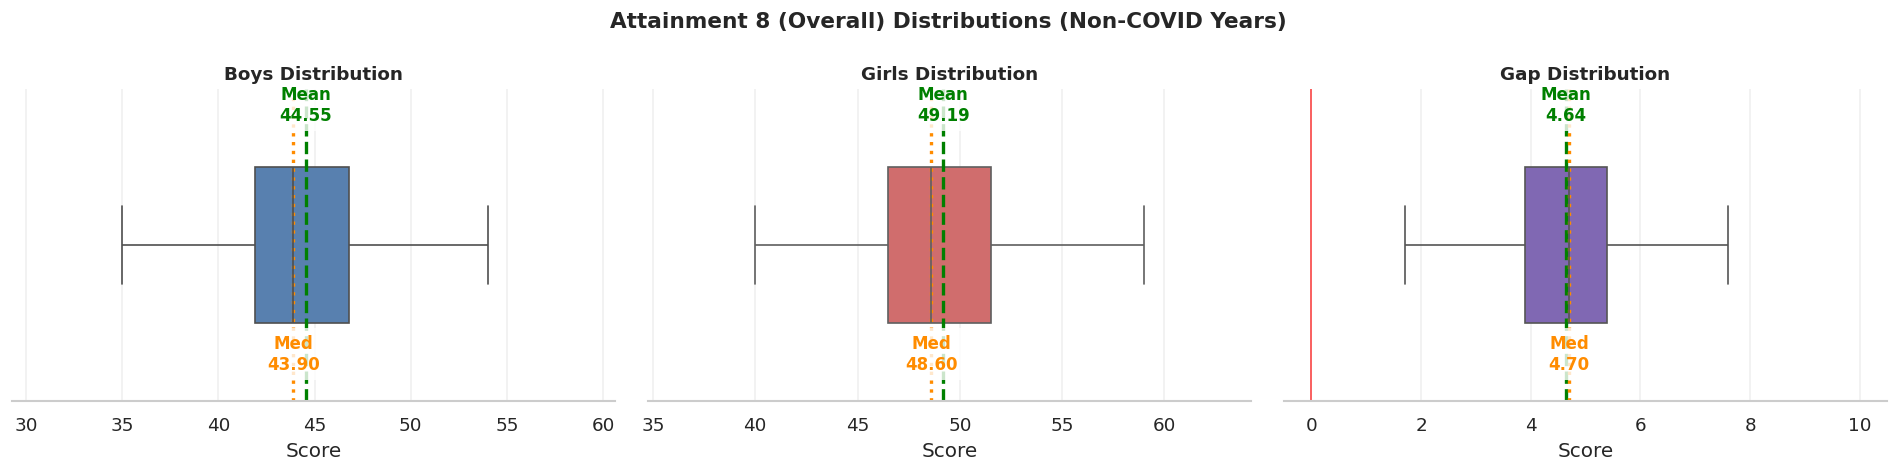

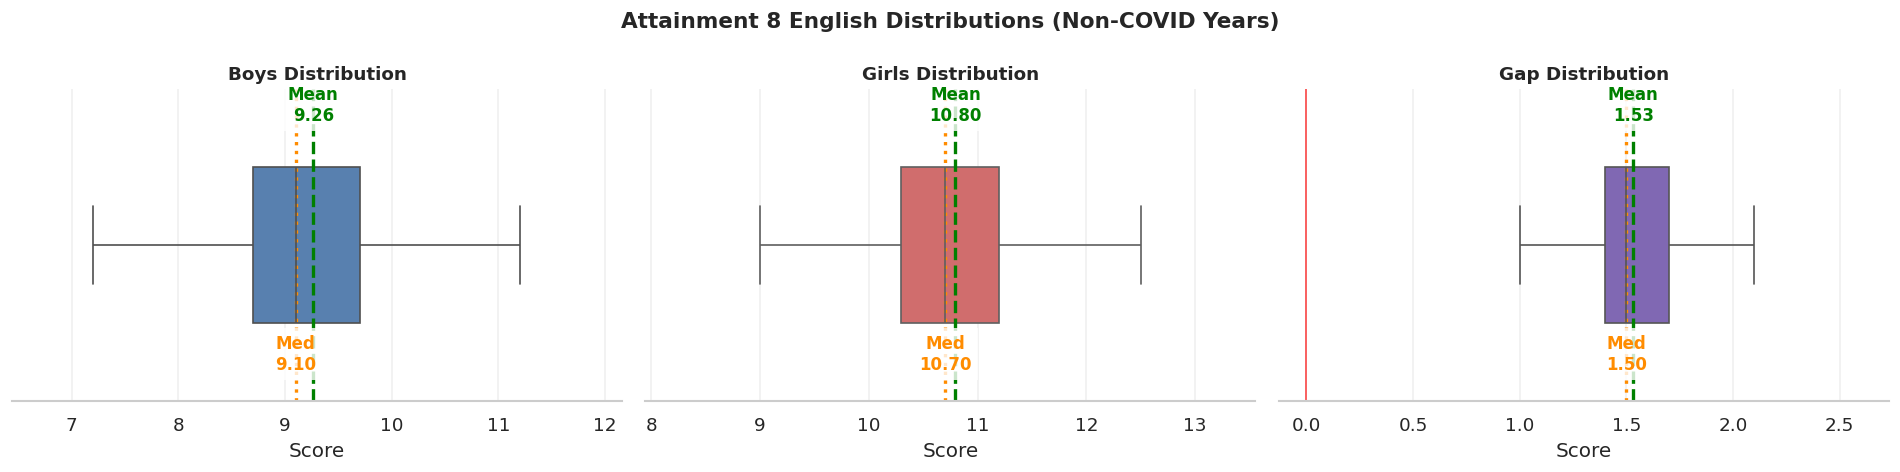

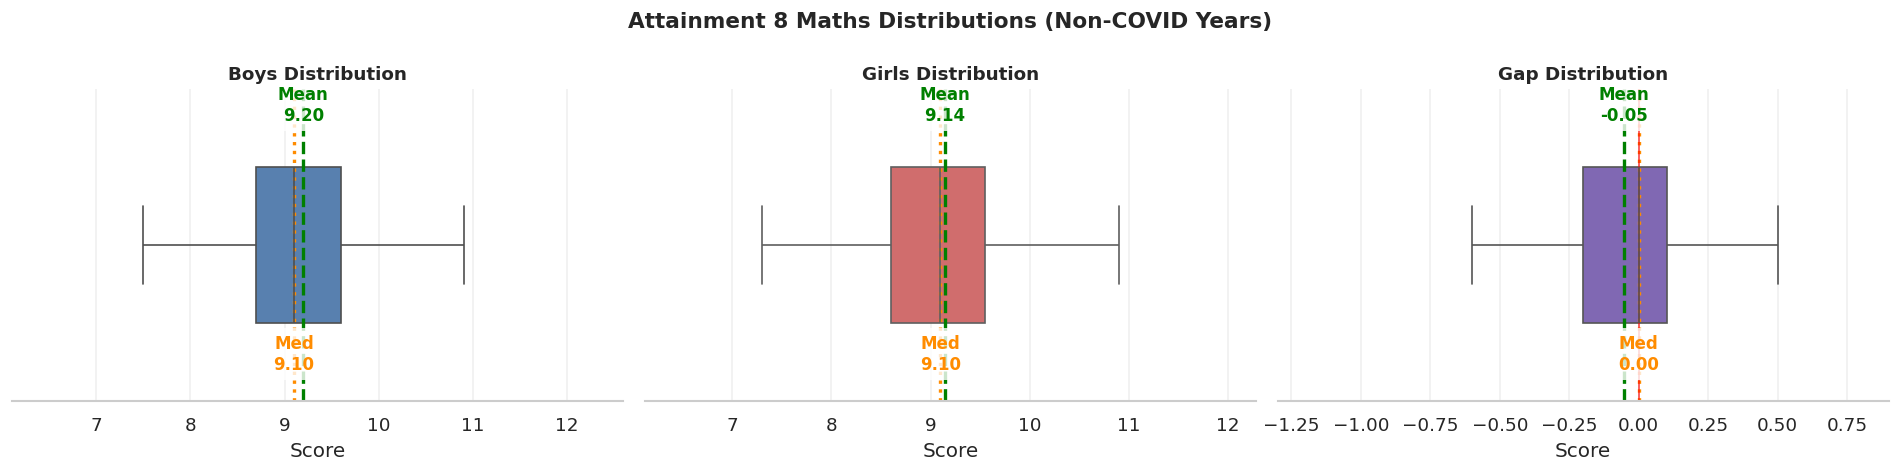

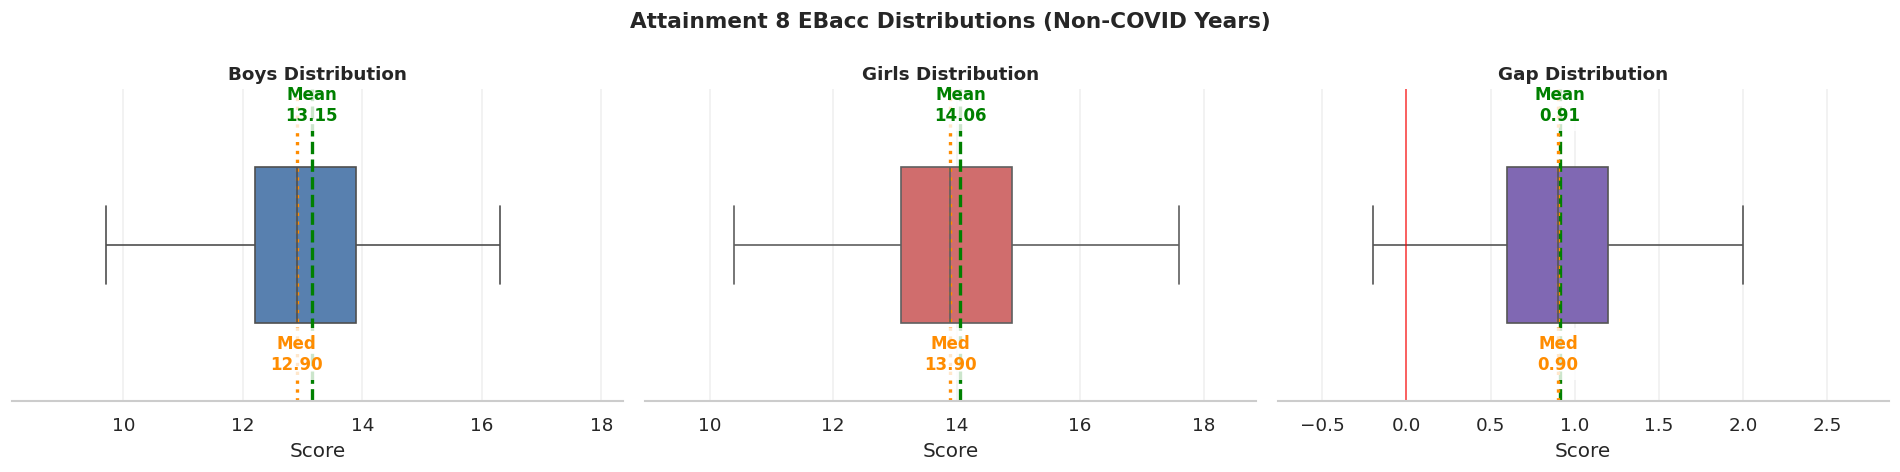

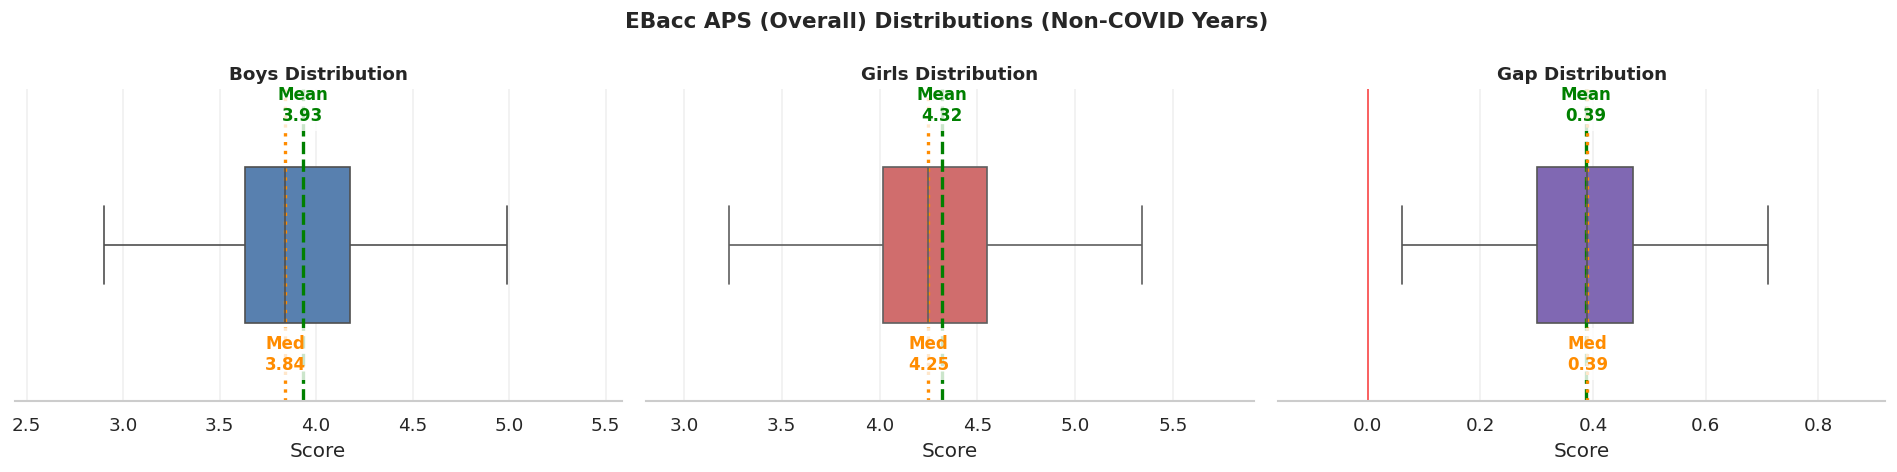

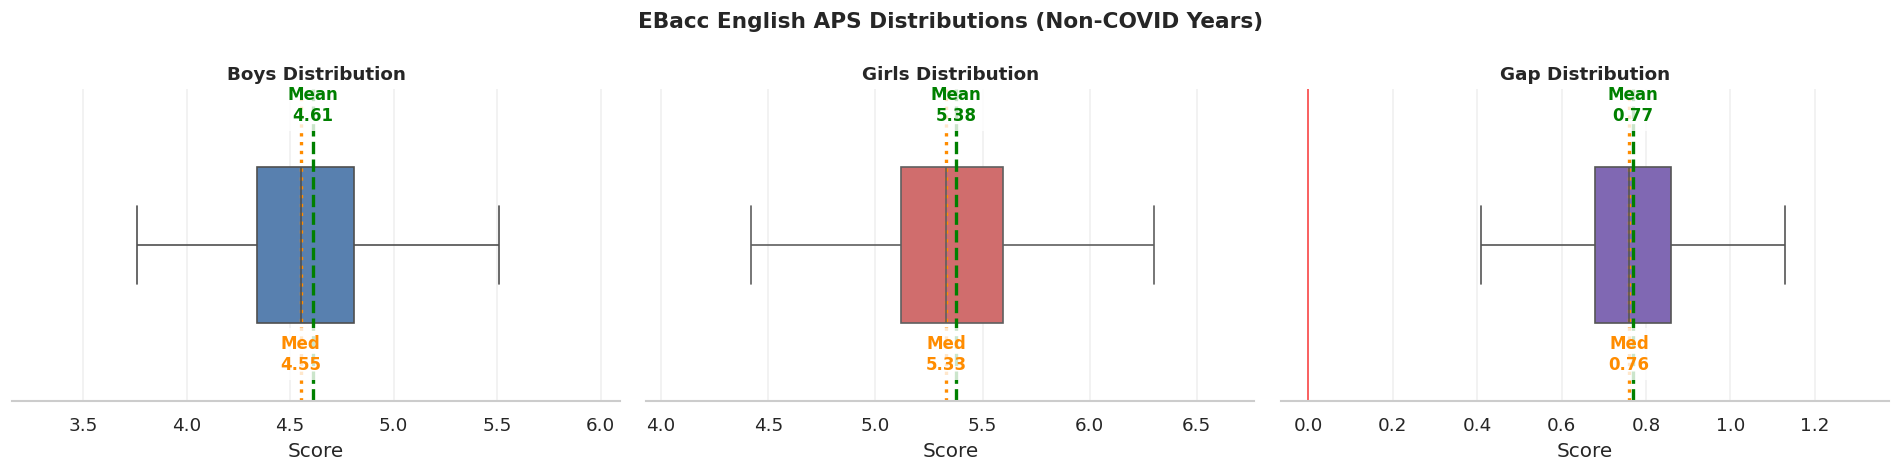

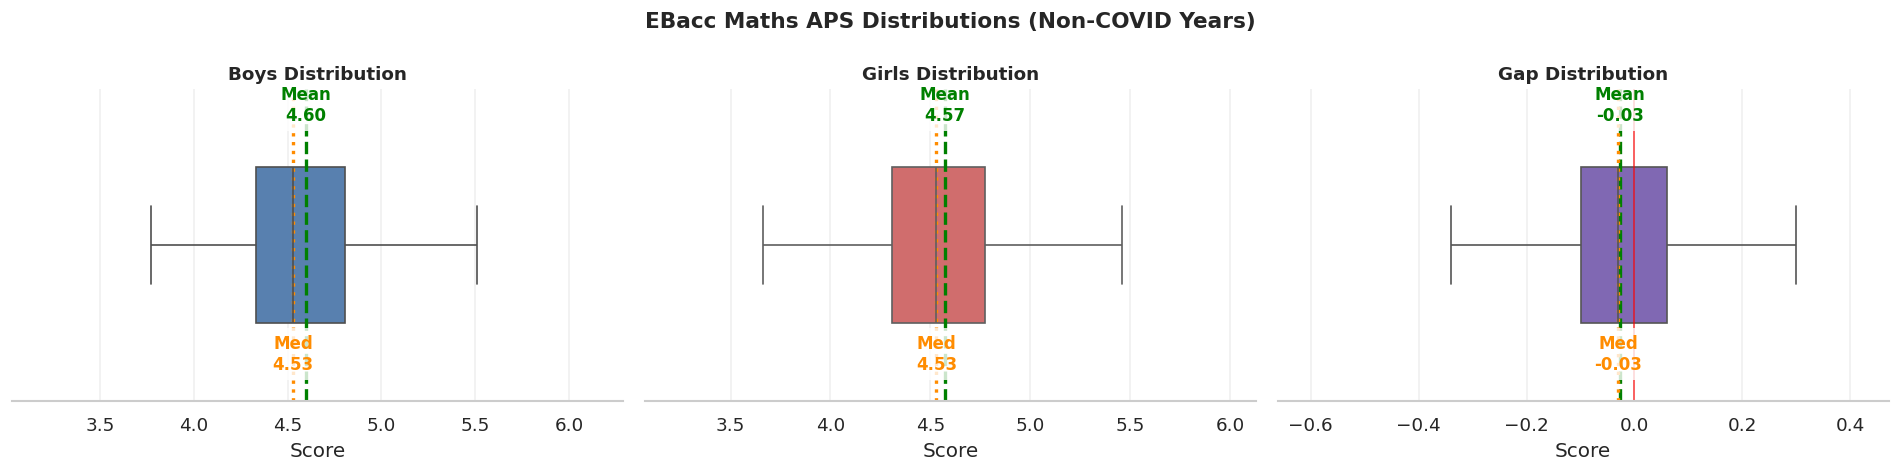

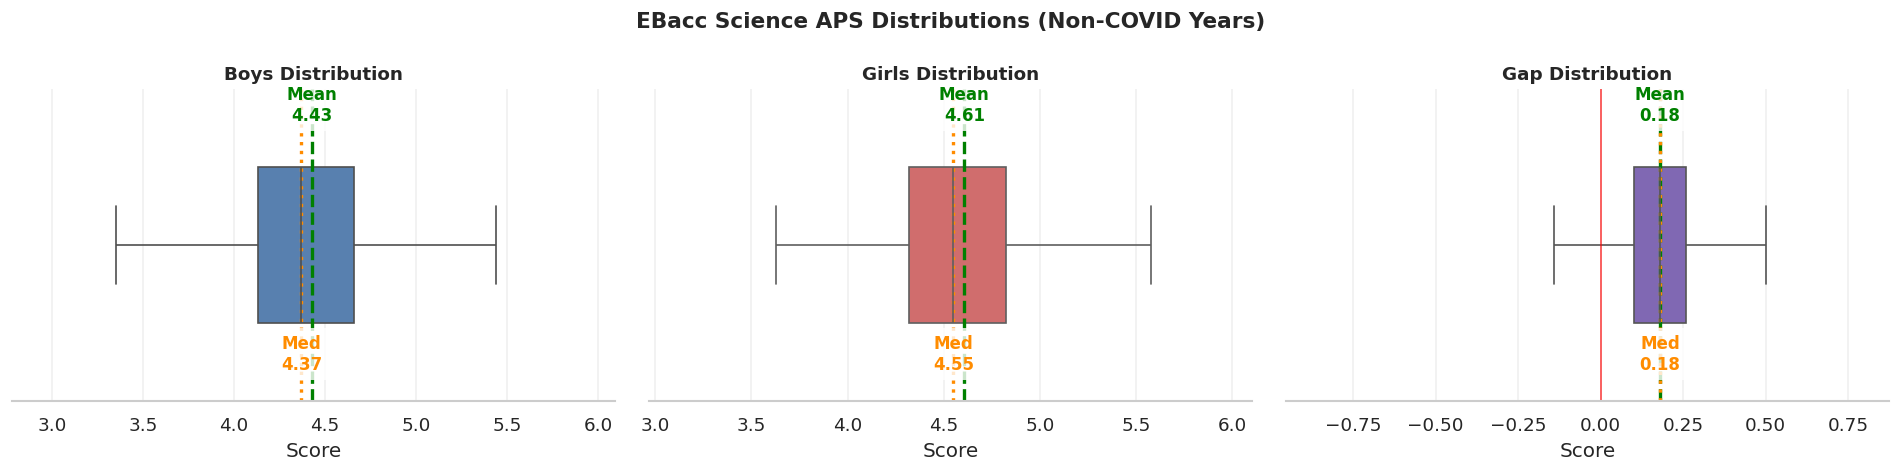

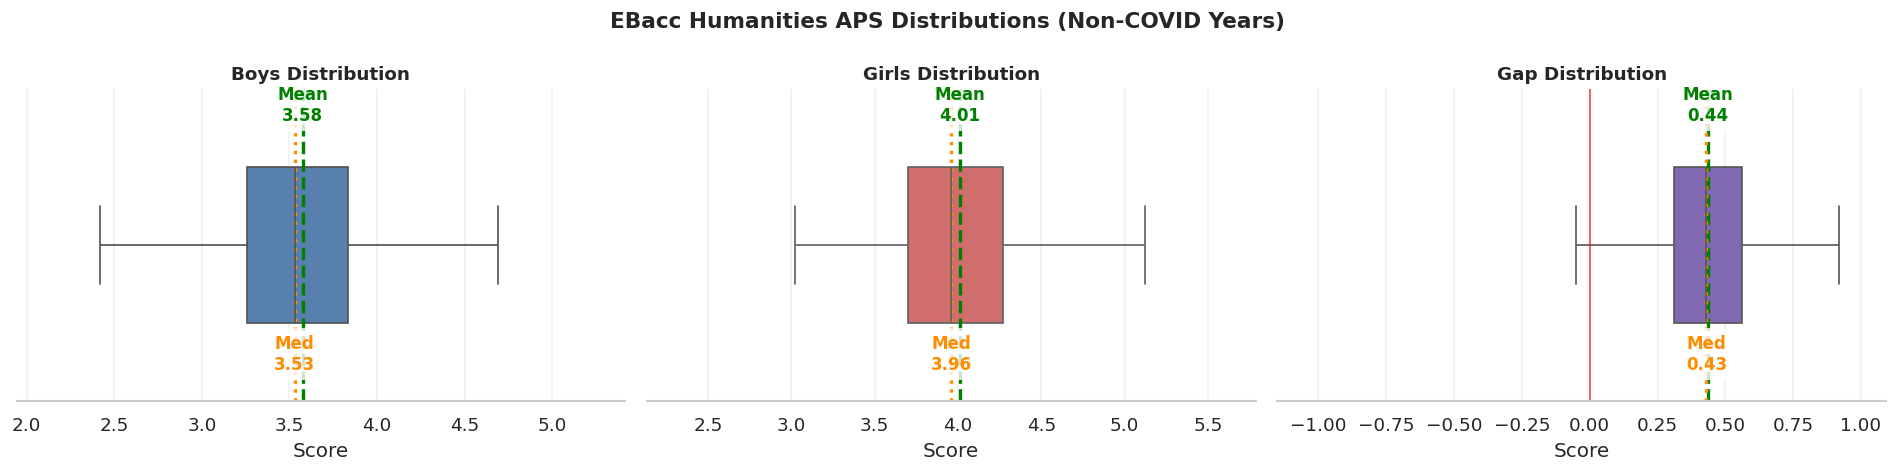

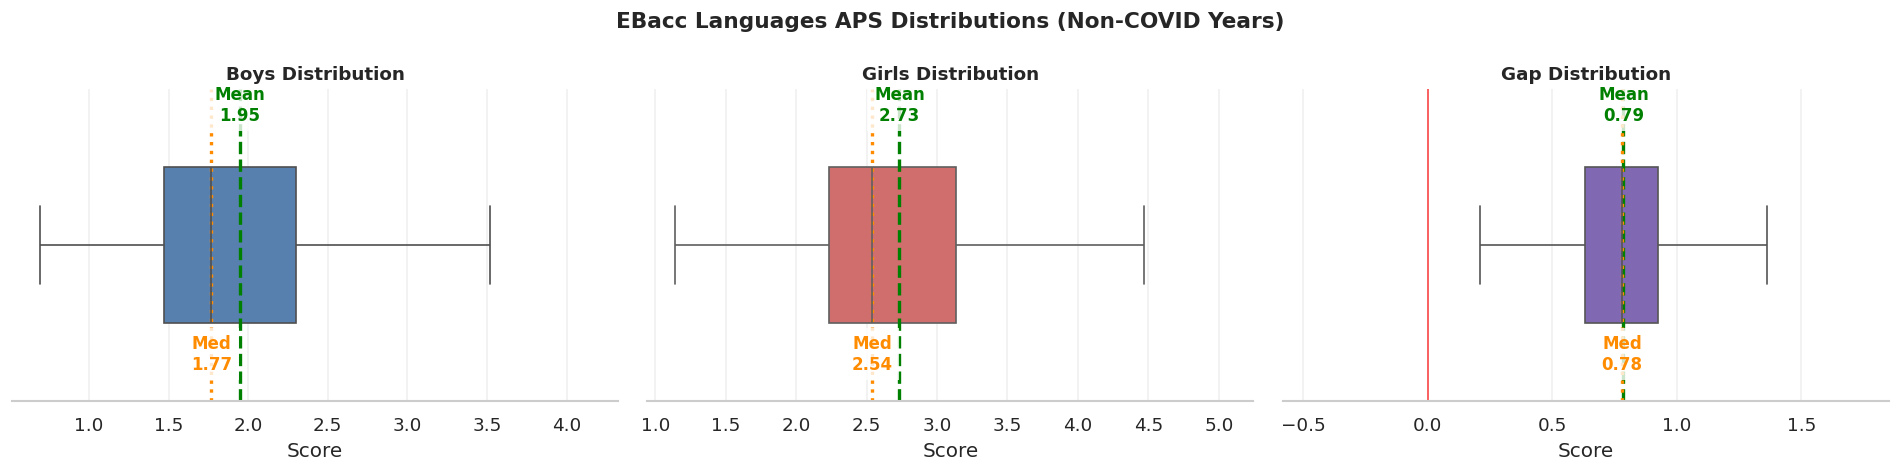

In [20]:
# Exclude COVID years (2020, 2021) for a clean structural analysis
df_no_covid = df[~df['end_year'].isin([2020, 2021])].copy()

# List of performance metrics and clean display names

col_mapping = {
    'attainment8_average': 'Attainment 8 (Overall)',
    'attainment8eng_average': 'Attainment 8 English',
    'attainment8mat_average': 'Attainment 8 Maths',
    'attainment8ebacc_average': 'Attainment 8 EBacc',
    'ebacc_aps_average': 'EBacc APS (Overall)',
    'ebacceng_aps_average': 'EBacc English APS',
    'ebaccmat_aps_average': 'EBacc Maths APS',
    'ebaccsci_aps_average': 'EBacc Science APS',
    'ebacchum_aps_average': 'EBacc Humanities APS',
    'ebacclan_aps_average': 'EBacc Languages APS'
}

perf_cols = list(col_mapping.keys()) # Plotting all metrics

for col in perf_cols:
    clean_name = col_mapping[col]
    
    # Align boys and girls by LA and year
    boys_df = df_no_covid[df_no_covid['sex'] == 'Boys'].set_index(['new_la_code', 'la_name', 'end_year'])
    girls_df = df_no_covid[df_no_covid['sex'] == 'Girls'].set_index(['new_la_code', 'la_name', 'end_year'])
    
    merged = pd.DataFrame({'Boys': boys_df[col], 'Girls': girls_df[col]}).dropna()
    merged['Gap'] = merged['Girls'] - merged['Boys']
    
    stats_dict = {
        'Boys': {'data': merged['Boys'].values, 'mean': merged['Boys'].mean(), 'median': merged['Boys'].median(), 'color': BOY_COL},
        'Girls': {'data': merged['Girls'].values, 'mean': merged['Girls'].mean(), 'median': merged['Girls'].median(), 'color': GIRL_COL},
        'Gap': {'data': merged['Gap'].values, 'mean': merged['Gap'].mean(), 'median': merged['Gap'].median(), 'color': GAP_COL}
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'{clean_name} Distributions (Non-COVID Years)', fontsize=13, fontweight='bold', y=0.98)
    
    for i, (group_name, info) in enumerate(stats_dict.items()):
        ax = axes[i]
        data_s = info['data']
        mean_val = info['mean']
        med_val = info['median']
        
        # Draw box plot
        sns.boxplot(x=data_s, ax=ax, color=info['color'], width=0.5, showfliers=True,
                    flierprops=dict(marker='o', markersize=4, alpha=0.4, markeredgecolor='none'))
        
        # Overlay mean and median lines
        ax.axvline(mean_val, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        ax.axvline(med_val, color='darkorange', linestyle=':', linewidth=2, label=f'Median: {med_val:.2f}')
        
        ax.set_title(f'{group_name} Distribution', fontsize=11, fontweight='bold')
        ax.set_xlabel('Score')
        
        # Display the numerical values on the plot
        ymin, ymax = ax.get_ylim()
        ax.text(mean_val, ymax - 0.1*(ymax-ymin), f'Mean\n{mean_val:.2f}', color='green', fontsize=10,
                ha='center', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        ax.text(med_val, ymin + 0.1*(ymax-ymin), f'Med\n{med_val:.2f}', color='darkorange', fontsize=10,
                ha='center', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
        if group_name == 'Gap':
            ax.axvline(0, color='red', linestyle='-', linewidth=1, alpha=0.7)
            
        ax.spines['left'].set_visible(False)
        ax.set_yticks([])
        ax.grid(True, axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### Statistical Conclusion: Justification for Using the Mean

From the visual distributions generated above, we can draw the following conclusions:

1. **Distribution Symmetry & Skewness**: 
   * The raw attainment scores for boys and girls separately exhibit moderate right-skewness because scores are bounded on the lower end by zero but have a long upper tail.
   * However, because both boys' and girls' distributions are skewed in the same direction, subtracting them to calculate the gender gap cancels out the skewness, resulting in highly symmetric gap distributions.
2. **Mean-Median Convergence**: 
   * In the raw attainment scores, the mean and median values are extremely close.
   * In the gap distributions, the mean and median are virtually identical.
3. **Decision**:
   * We will proceed using the **mean** as our measure of central tendency for the exploratory data analysis. This choice ensures mathematical consistency (the mean gap is exactly the difference between the mean scores of girls and boys) and supports the standard parametric statistical methods (such as Pearson correlation and ANOVA) used in the remainder of this analysis.

## 4. Deprivation Quintiles

We assign each Local Authority to one of five deprivation **quintiles** based on its mean IMD score across all years. Quintile 1 = least deprived; Quintile 5 = most deprived.

> **Note:** The IMD score is fixed at 2019 values, so the quintile is constant across years for each LA.

In [21]:
quintile_order = ["Q1 (Least deprived)", "Q2", "Q3 (Median)", "Q4", "Q5 (Most deprived)"]

# Derive a single IMD score per LA (mean across years — should be constant)
la_imd = gap.groupby("new_la_code")["imd_score"].mean()

# Assign quintiles (1 = least deprived, 5 = most deprived)
la_quintile = pd.qcut(
    la_imd,
    q=5,
    labels=["Q1 (Least deprived)",
            "Q2",
            "Q3 (Median)",
            "Q4",
            "Q5 (Most deprived)"],
    retbins=False
).rename("dep_quintile")

gap = gap.merge(la_quintile.reset_index(), on="new_la_code", how="left")

# COVID flag: years where exams were cancelled / teacher-assessed
gap["covid_year"] = gap["end_year"].isin([2020, 2021])

print("Quintile distribution of Local Authorities:")
print(gap.drop_duplicates("new_la_code")["dep_quintile"].value_counts().sort_index())

Quintile distribution of Local Authorities:
dep_quintile
Q1 (Least deprived)    31
Q2                     30
Q3 (Median)            31
Q4                     30
Q5 (Most deprived)     31
Name: count, dtype: int64


## 5. Exploratory Data Analysis


### 5.1 — National gender gap over time


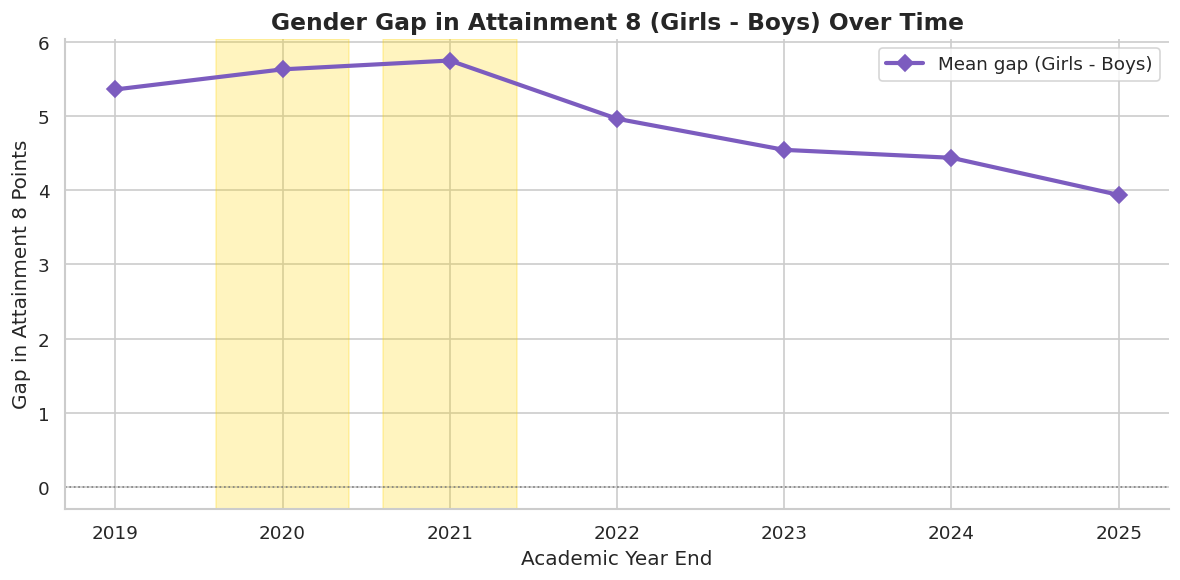


Mean gap (Girls - Boys Attainment 8) by year:
 end_year  mean_gap_pts
     2019      5.358219
     2020      5.629252
     2021      5.747973
     2022      4.963514
     2023      4.544371
     2024      4.437748
     2025      3.937748


In [22]:
# Mean gender gap per year (across all LAs)
gap_by_year = (
    gap.groupby('end_year')['gap_attainment8_average']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(gap_by_year['end_year'], gap_by_year['gap_attainment8_average'],
        color=GAP_COL, linewidth=2.5, marker='D', markersize=7,
        label='Mean gap (Girls - Boys)')
ax.axhline(0, color='grey', linewidth=1, linestyle=':')

for yr in [2020, 2021]:
    ax.axvspan(yr - 0.4, yr + 0.4, color=COVID_COL, alpha=0.25)

ax.set_title('Gender Gap in Attainment 8 (Girls - Boys) Over Time',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Academic Year End')
ax.set_ylabel('Gap in Attainment 8 Points')
ax.set_xticks(sorted(gap['end_year'].unique()))
ax.legend()
plt.tight_layout()
plt.show()

print('\nMean gap (Girls - Boys Attainment 8) by year:')
print(gap_by_year[['end_year','gap_attainment8_average']].rename(
    columns={'gap_attainment8_average':'mean_gap_pts'}).to_string(index=False))


## 6. Gender Gap across Deprivation Quintiles

### 6.1 — Box plot: distribution of gender gap by quintile

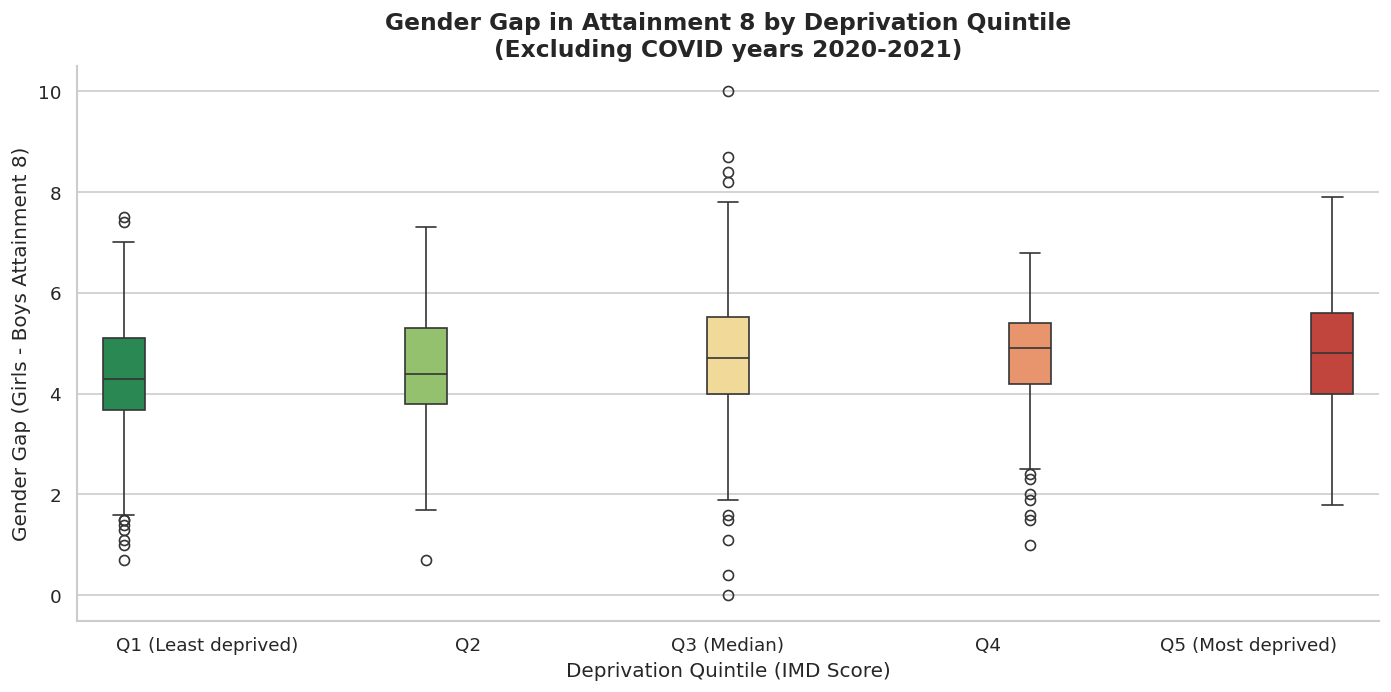

In [23]:
# Exclude COVID years for a cleaner picture of structural patterns
gap_no_covid = gap[~gap["covid_year"]].copy()

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=gap_no_covid,
    x="dep_quintile",
    y="gap_attainment8_average",
    hue="dep_quintile",
    palette=QUINT_PALETTE,
    ax=ax
)

ax.set_title("Gender Gap in Attainment 8 by Deprivation Quintile\n"
             "(Excluding COVID years 2020-2021)",
             fontsize=14, fontweight="bold"
)
ax.set_xlabel("Deprivation Quintile (IMD Score)", fontsize=12)
ax.set_ylabel("Gender Gap (Girls - Boys Attainment 8)", fontsize=12)
plt.setp(ax.get_xticklabels(), ha="center")

plt.show()
